In [1]:
#ASSIGNMENT 4: LOGISTIC REGRESSION AND SVM
#LOADING DATASET

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, RocCurveDisplay, classification_report
)
'''rcParams['font.family']='Liberation Serif'
rcParams['font.weight']='bold'
rcParams['font.size']=15
rcParams['axes.labelweight']='bold'
rcParams['axes.titleweight']='bold'
rcParams['xtick.labelsize']=15
rcParams['ytick.labelsize']=15'''
df = pd.read_csv("spambase_csv_Kaggle.csv")
df

def save_eps_and_show(fig=None, prefix="assign4"):
    """
    Saves the current figure (or provided fig) as EPS @ 600 DPI
    with an auto-incremented filename, then shows it.
    """
    global PLOT_COUNTER
    if fig is None:
        fig = plt.gcf()
    fname = f"{prefix}_{PLOT_COUNTER}.eps"
    fig.savefig(fname, format="eps", dpi=600, bbox_inches="tight")
    PLOT_COUNTER += 1
    plt.show()

In [2]:
print("Shape:", df.shape)
print("\nHead:\n", df.head())
print("\nMissing values per column (top 10):\n", df.isna().sum().sort_values(ascending=False).head(10))

Shape: (4601, 58)

Head:
    word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_%3B  char_freq_%28  \
0             0.00            0.00  ...  

In [3]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\n=== Column Types ===")
print("Numeric columns:", numeric_cols)
print("Categorical/bool columns:", cat_cols)

print("\n Missing Values (count & %)")
miss_count = df.isna().sum().sort_values(ascending=False)
miss_pct = (miss_count / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": miss_count, "missing_pct": miss_pct})
print(missing_table[missing_table["missing_count"] > 0])

dup = df.duplicated().sum()
print(f"\n=== Duplicates ===\nDuplicates: {dup}")


=== Column Types ===
Numeric columns: ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_%3B', 'char_freq_%28', 'char_freq_%5B', 'char_f

In [4]:
df = df.drop_duplicates()
df.shape

(4210, 58)

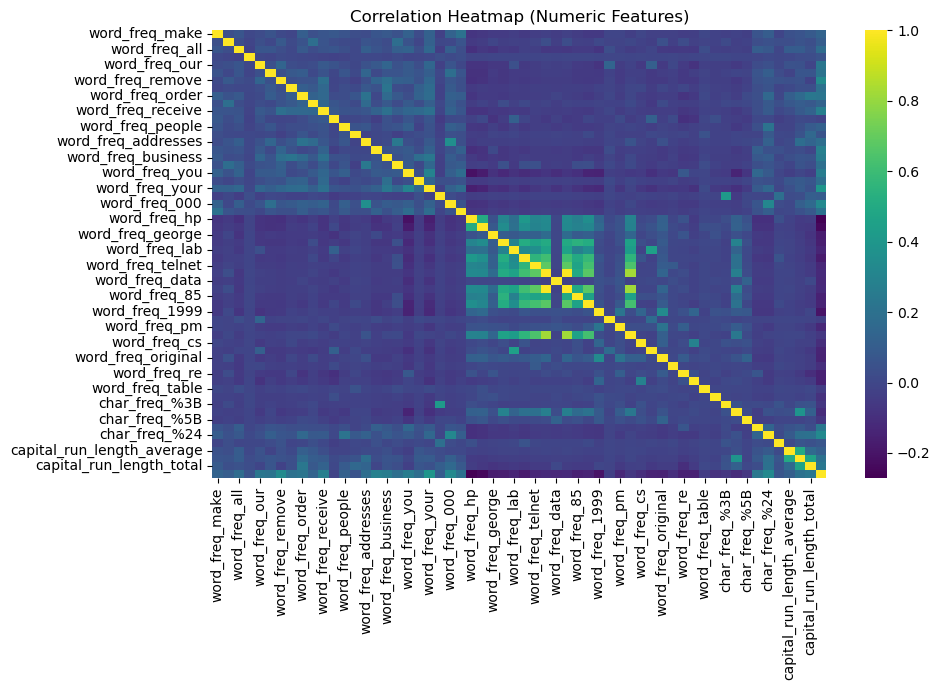

<Figure size 640x480 with 0 Axes>

In [5]:
#EDA USING HEATMAP AND HISTOGRAMS
corr = df[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=False, cmap="viridis")
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()
plt.savefig( "assign2_1.eps", format="eps", dpi=600, bbox_inches="tight" )

In [6]:

target_col = "class"
print("\nDetected target column:", target_col)



Detected target column: class


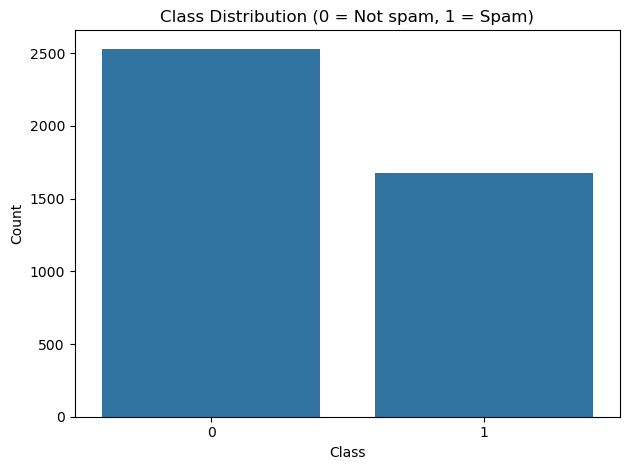

<Figure size 640x480 with 0 Axes>

In [7]:
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

for c in X.columns:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X = X.fillna(X.median(numeric_only=True))

if y.isna().any():
    y = y.fillna(y.mode().iloc[0])
plt.figure()
sns.countplot(x=y)
plt.title("Class Distribution (0 = Not spam, 1 = Spam)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
plt.savefig( "assign4.eps", format="eps", dpi=600, bbox_inches="tight" )

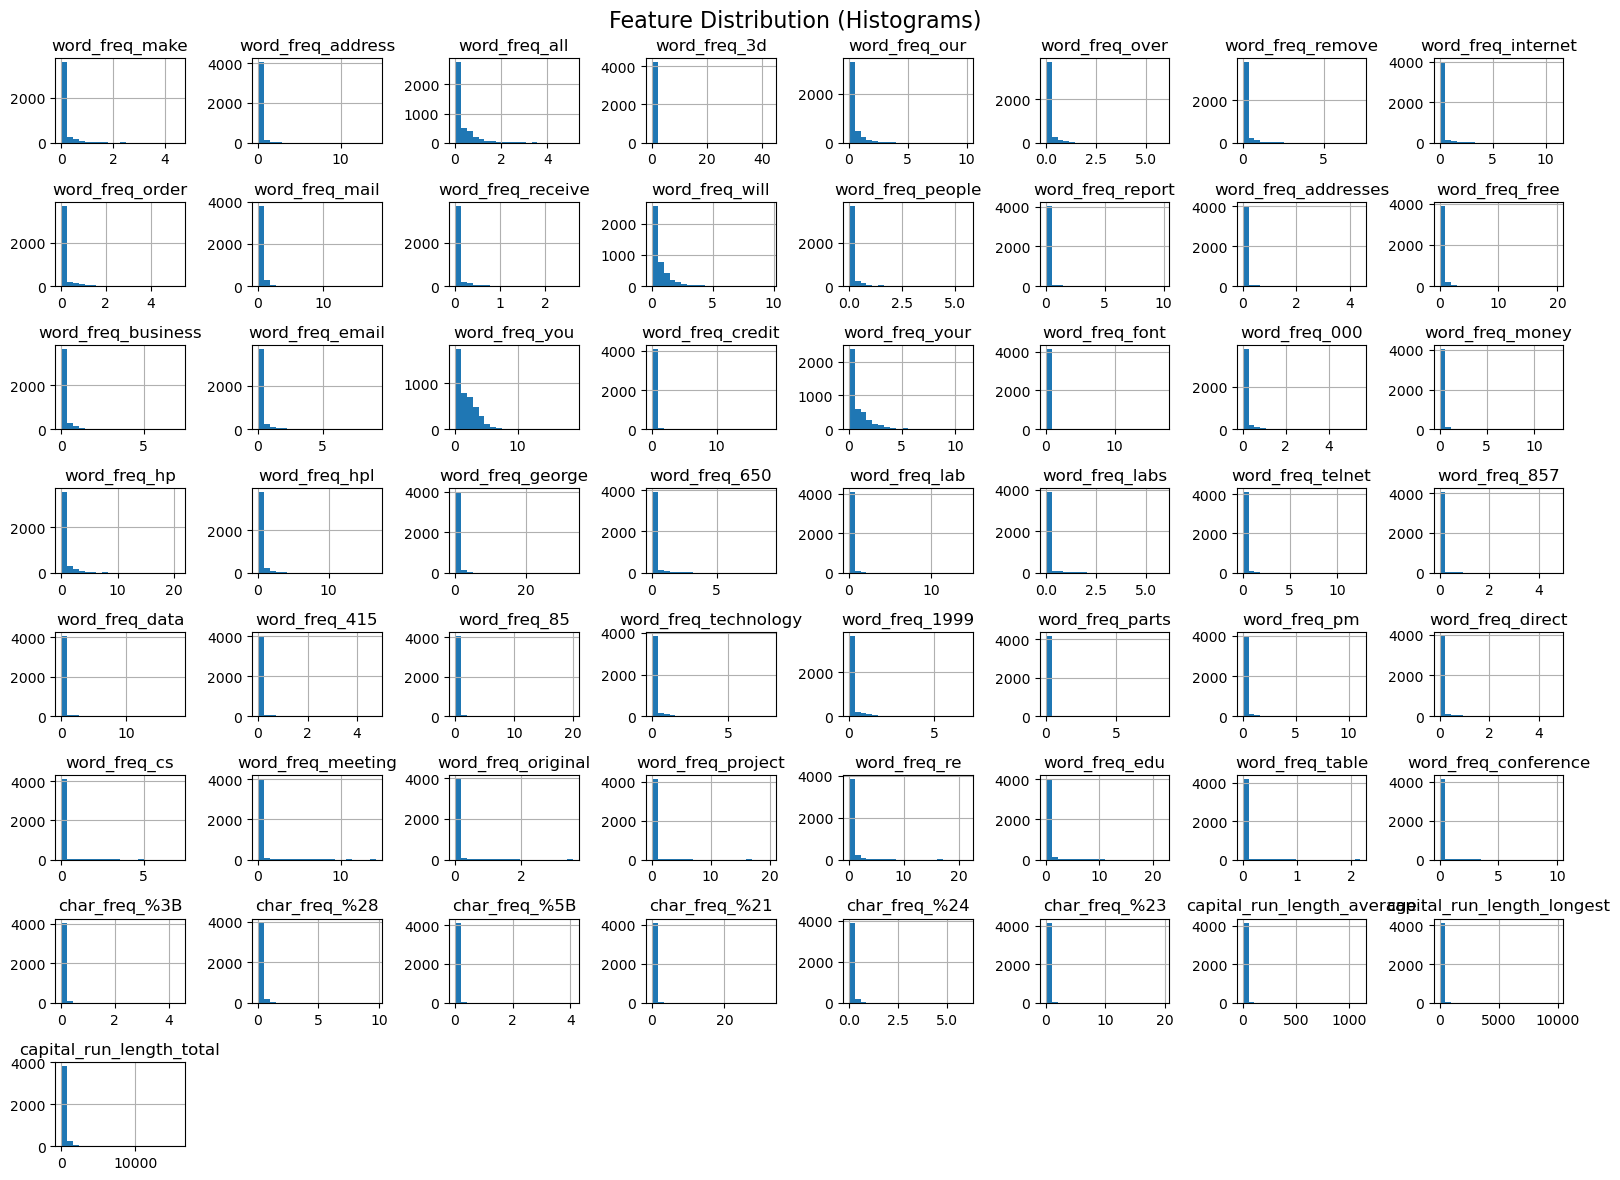

<Figure size 640x480 with 0 Axes>

In [8]:
X.hist(bins=20, figsize=(16, 12))
plt.suptitle("Feature Distribution (Histograms)", fontsize=16)
plt.tight_layout()
plt.show()
plt.savefig( "assign2_3.eps", format="eps", dpi=600, bbox_inches="tight" ) 

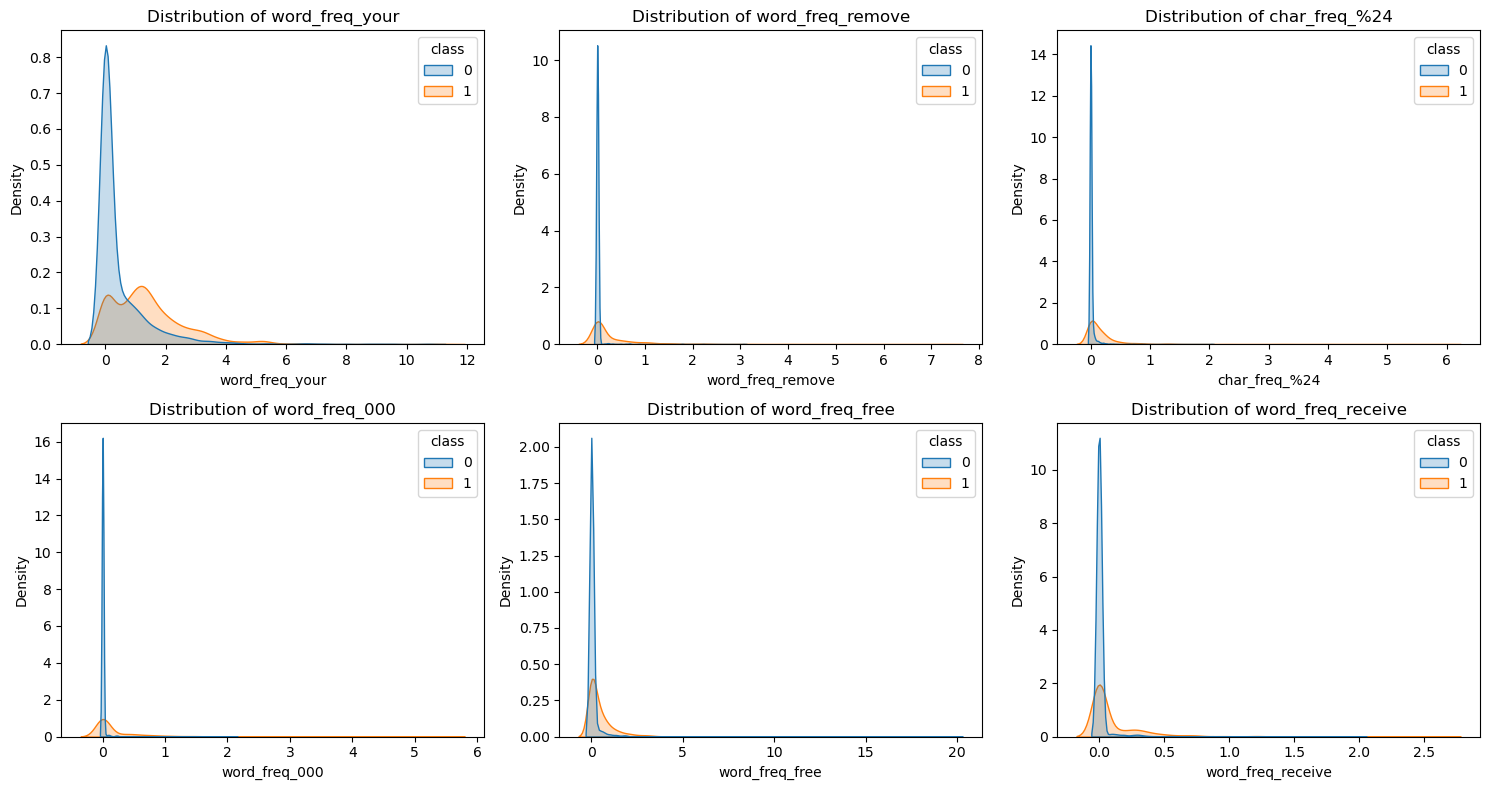

<Figure size 640x480 with 0 Axes>

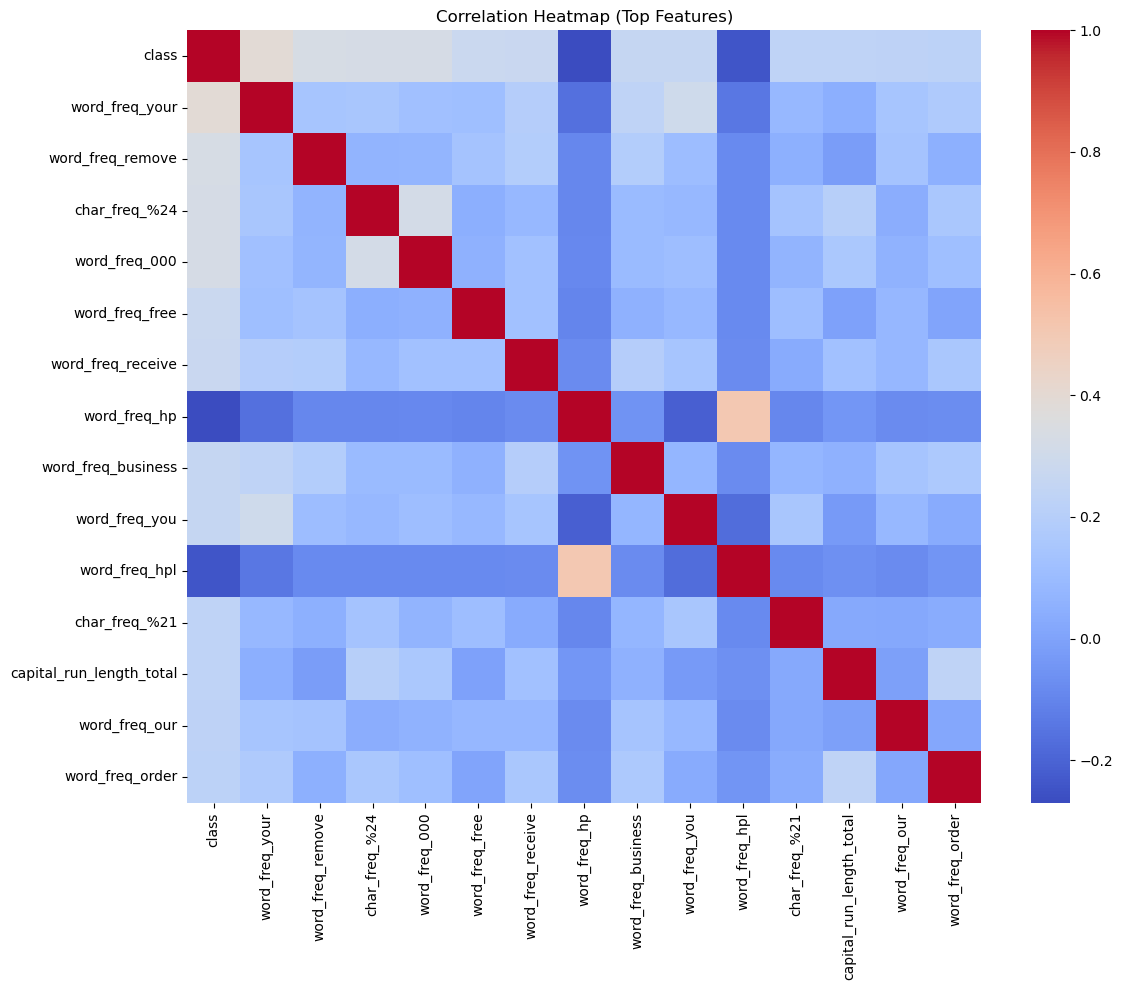

<Figure size 640x480 with 0 Axes>

In [9]:
# 3. Feature Distribution by Class (KDE plots)
df_corr = df.corr(numeric_only=True)[target_col].abs().sort_values(ascending=False)
top_features = df_corr.index[1:7]  # skip target itself

plt.figure(figsize=(15, 8))
for i, feature in enumerate(top_features, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(data=df, x=feature, hue=target_col, fill=True)
    plt.title(f"Distribution of {feature}")
plt.tight_layout()
plt.show()
plt.savefig( "assign2_4.eps", format="eps", dpi=600, bbox_inches="tight" ) 
# 5. Correlation Heatmap (Top Features)

top_corr_features = df_corr.head(15).index

plt.figure(figsize=(12, 10))
sns.heatmap(df[top_corr_features].corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (Top Features)")
plt.tight_layout()
plt.show()
plt.savefig( "assign2_5.eps", format="eps", dpi=600, bbox_inches="tight" )

In [13]:
#Includes Evaluation, Confusion matrix, Roc curve
def get_scores_for_roc(model, X_scaled):
    # For ROC: prefer predict_proba if available, else decision_function
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_scaled)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X_scaled)
    return None
def evaluate_scaled_model(name, model, X_test_scaled, y_test):
    t0 = time.time()
    y_pred = model.predict(X_test_scaled)
    infer_time = time.time() - t0

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n==== {name} ====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Inference time (s): {infer_time:.4f}")
    print("\nClassification report:\n", classification_report(y_test, y_pred, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    plt.title(f"Confusion Matrix: {name}")
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    save_eps_and_show(fig, prefix="assign4")

    # ROC curve
    scores = get_scores_for_roc(model, X_test_scaled)
    if scores is not None:
        fpr, tpr, _ = roc_curve(y_test, scores)
        roc_auc = auc(fpr, tpr)
        fig, ax = plt.subplots(figsize=(6, 5))
        RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=name).plot(ax=ax)
        plt.title(f"ROC Curve: {name} (AUC={roc_auc:.4f})")
        save_eps_and_show(fig, prefix="assign4")
    else:
        print("ROC not plotted: model provides neither predict_proba nor decision_function.")

    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "inference_time_s": infer_time}

In [14]:
#STANDARDTIZE THE DATASET
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Model trained with standardised features")


Model trained with standardised features



Baseline Logistic Regression training time (s): 0.0832

==== Baseline Logistic Regression ====
Accuracy : 0.9145
Precision: 0.9284
Recall   : 0.8663
F1 Score : 0.8963
Inference time (s): 0.0025

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93       483
           1       0.93      0.87      0.90       359

    accuracy                           0.91       842
   macro avg       0.92      0.91      0.91       842
weighted avg       0.92      0.91      0.91       842



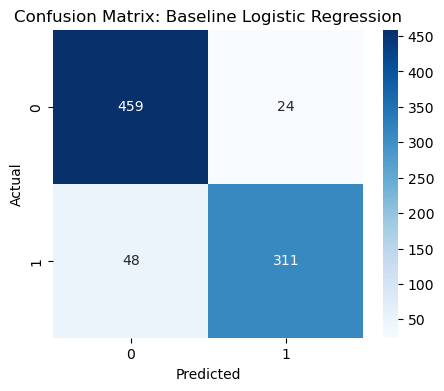

C:\Users\kisho\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:379: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


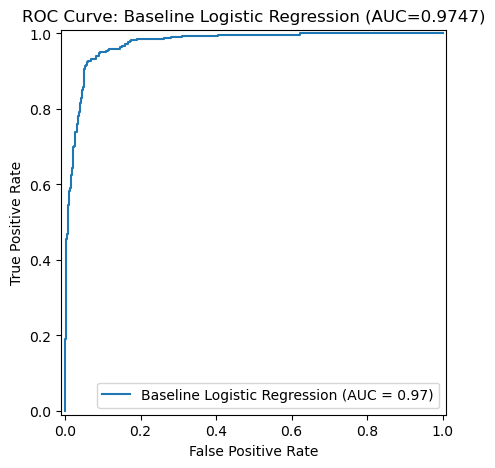

In [15]:
#Use Base Logistic Regression
PLOT_COUNTER = 0

#Use Base Logistic Regression
baseline_lr = LogisticRegression(max_iter=500, random_state=42)

t0 = time.time()
baseline_lr.fit(X_train_scaled, y_train)
train_time_lr = time.time() - t0
print(f"\nBaseline Logistic Regression training time (s): {train_time_lr:.4f}")

metrics_lr_base = evaluate_scaled_model(
    "Baseline Logistic Regression",
    baseline_lr,
    X_test_scaled,
    y_test
)

In [16]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scores_base = cross_val_score(
    baseline_lr,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring='accuracy'
)
print("Base Logistic Regression Accuracy: ",cv_scores_base.mean())



Base Logistic Regression Accuracy:  0.917457594984149


In [17]:
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}

# Grid Search
lr_grid = GridSearchCV(
    baseline_lr,
    param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

# Fit
lr_grid.fit(X_train_scaled, y_train)

# Results
print("Grid Best Params:", lr_grid.best_params_)
print("Grid Best CV Accuracy:", lr_grid.best_score_)

Grid Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Grid Best CV Accuracy: 0.9207238945154563



Best LR Test Metrics:
Accuracy : 0.9216
Precision: 0.9347
Recall   : 0.8774
F1 Score : 0.9052

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93       483
           1       0.93      0.88      0.91       359

    accuracy                           0.92       842
   macro avg       0.92      0.92      0.92       842
weighted avg       0.92      0.92      0.92       842



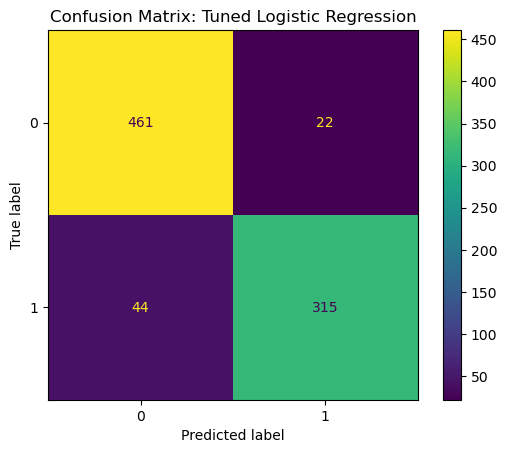

C:\Users\kisho\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:379: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


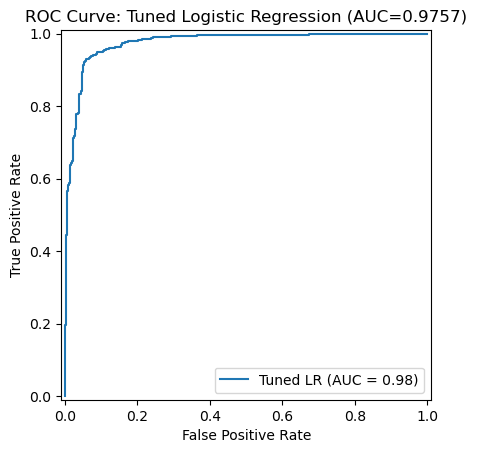

In [18]:
best_lr = lr_grid.best_estimator_
import time
# ---- Predictions ----
y_pred = best_lr.predict(X_test_scaled)

print("\nBest LR Test Metrics:")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred, zero_division=0), 4))

print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

# ---- Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix: Tuned Logistic Regression")
save_eps_and_show(prefix="assign4")

# ---- ROC Curve ----
# Try predict_proba first; if not available, use decision_function
if hasattr(best_lr, "predict_proba"):
    scores = best_lr.predict_proba(X_test_scaled)[:, 1]
else:
    scores = best_lr.decision_function(X_test_scaled)

fpr, tpr, _ = roc_curve(y_test, scores)
roc_auc = auc(fpr, tpr)

RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="Tuned LR").plot()
plt.title(f"ROC Curve: Tuned Logistic Regression (AUC={roc_auc:.4f})")
save_eps_and_show(prefix="assign4")

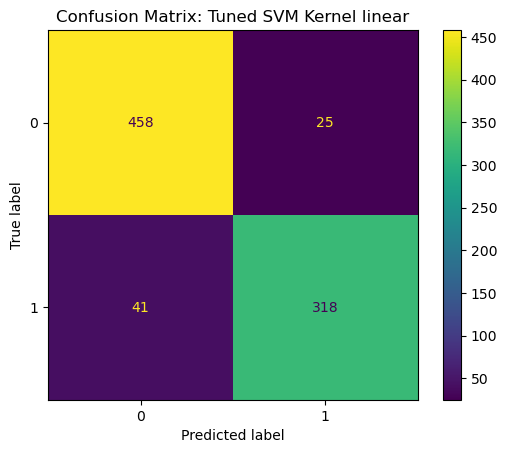

C:\Users\kisho\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:379: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


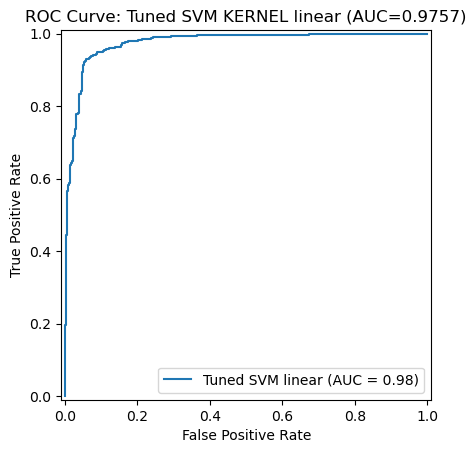

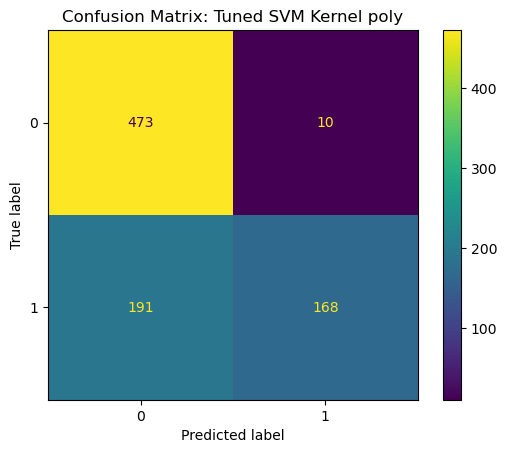

C:\Users\kisho\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:379: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


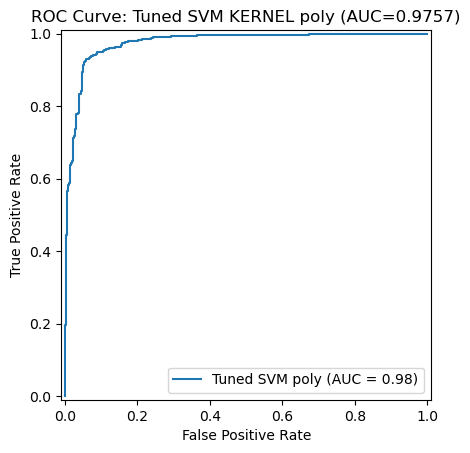

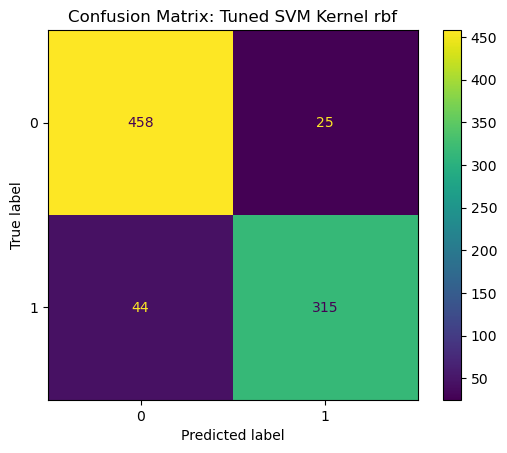

C:\Users\kisho\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:379: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


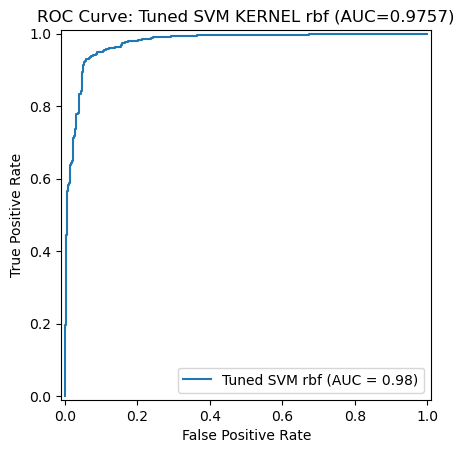

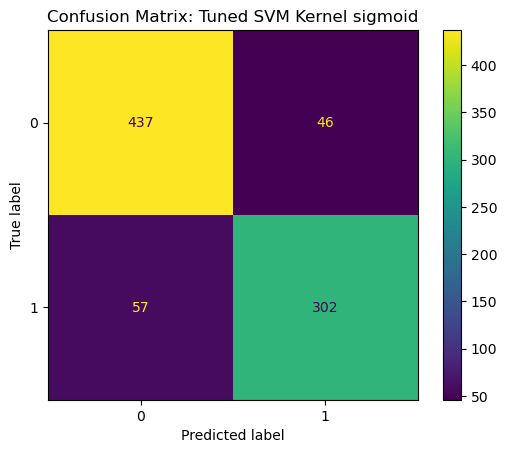

C:\Users\kisho\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:379: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


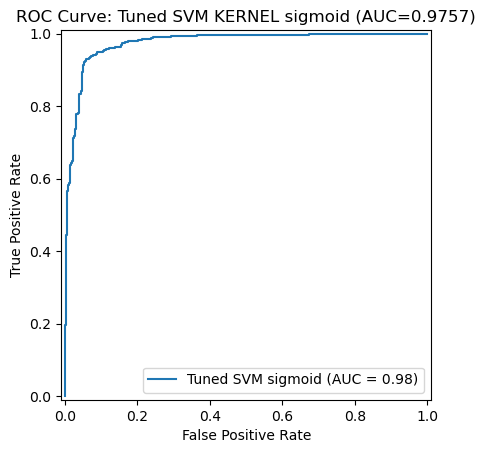


SVM Kernel-wise Performance
    Kernel  Accuracy  F1 Score  Training Time (s)
    Linear    0.9216    0.9060             0.8057
Polynomial    0.7613    0.6257             0.7682
       Rbf    0.9181    0.9013             0.5034
   Sigmoid    0.8777    0.8543             0.4352


In [19]:
#NOW, USING SVM AND calculating accuracy for each kernel:
import time
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# Assumes you already have:
# X_train_mm, X_test_mm, y_train, y_test
# (where X_*_mm are already scaled/normalized like you used for LR)

kernels = ["linear", "poly", "rbf", "sigmoid"]
rows = []

for k in kernels:
    svm = SVC(kernel=k, random_state=42)

    t0 = time.time()
    svm.fit(X_train_scaled, y_train)
    train_time = time.time() - t0

    y_pred = svm.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    rows.append({
        "Kernel": "Polynomial" if k == "poly" else k.capitalize(),
        "Accuracy": round(acc, 4),
        "F1 Score": round(f1, 4),
        "Training Time (s)": round(train_time, 4)
    })
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix: Tuned SVM Kernel {k}")
    save_eps_and_show(prefix="assign4")
    if hasattr(best_lr, "predict_proba"):
        scores = best_lr.predict_proba(X_test_scaled)[:, 1]
    else:
        scores = best_lr.decision_function(X_test_scaled)

    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)

    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=f"Tuned SVM {k}").plot()
    plt.title(f"ROC Curve: Tuned SVM KERNEL {k} (AUC={roc_auc:.4f})")
    save_eps_and_show(prefix="assign4")

svm_kernelwise_df = pd.DataFrame(rows, columns=["Kernel", "Accuracy", "F1 Score", "Training Time (s)"])
print("\nSVM Kernel-wise Performance")
print(svm_kernelwise_df.to_string(index=False))


In [20]:
# Find best kernel
best_kernel_row = svm_kernelwise_df.loc[svm_kernelwise_df['Accuracy'].idxmax()]
best_kernel = best_kernel_row['Kernel']
best_kernel = "rbf"
# Convert kernel name back to lowercase format for sklearn
if best_kernel == "Polynomial":
    best_kernel = "poly"
elif best_kernel in ["Linear", "Rbf", "Sigmoid"]:
    best_kernel = best_kernel.lower()
param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10, 100]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']},
    {'kernel': ['poly'], 'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'degree': [2, 3]},
    {'kernel': ['sigmoid'], 'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}
]

svm_grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)
svm_grid.fit(X_train_scaled, y_train)
print("Best Params:", svm_grid.best_params_)
print("Best CV Accuracy:", svm_grid.best_score_)

Best Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy: 0.9302264981194968


In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

#Using K-FOLD COMPARISON BETWEEN SVM AND LOGISTIC REGRESSSION
best_svm = svm_grid
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_scores = []
svm_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train), start=1):
    X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Logistic Regression
    best_lr.fit(X_tr, y_tr)
    lr_pred = best_lr.predict(X_val)
    lr_scores.append(accuracy_score(y_val, lr_pred))

    # SVM
    best_svm.fit(X_tr, y_tr)
    svm_pred = best_svm.predict(X_val)
    svm_scores.append(accuracy_score(y_val, svm_pred))
    

# Create table
cv_results = pd.DataFrame({
    "Fold": [f"Fold {i}" for i in range(1, 6)] + ["Average"],
    "Logistic Regression": lr_scores + [float(np.mean(lr_scores))],
    "SVM": svm_scores + [float(np.mean(svm_scores))]
})

cv_results["Logistic Regression"] = cv_results["Logistic Regression"].round(4)
cv_results["SVM"] = cv_results["SVM"].round(4)

print("\nK-Fold Cross-Validation Results (K = 5)\n")
print(cv_results.to_string(index=False))



K-Fold Cross-Validation Results (K = 5)

   Fold  Logistic Regression    SVM
 Fold 1               0.9199 0.9199
 Fold 2               0.9258 0.9303
 Fold 3               0.9184 0.9377
 Fold 4               0.9123 0.9272
 Fold 5               0.9272 0.9361
Average               0.9207 0.9302


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


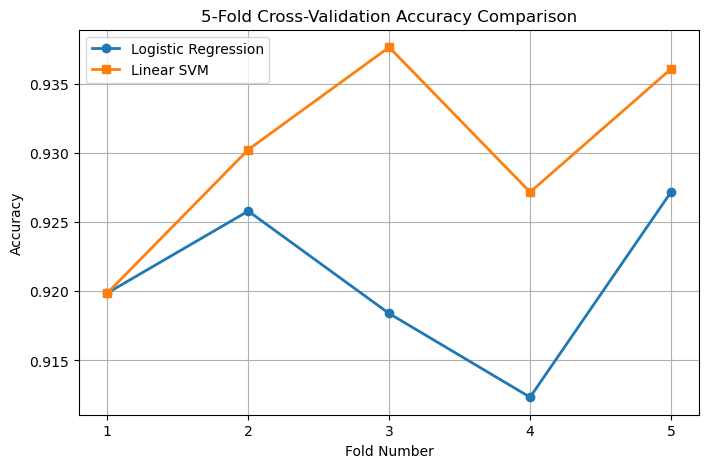

In [22]:
# Fold numbers
folds = np.arange(1, 6)

plt.figure(figsize=(8, 5))

plt.plot(folds, lr_scores, marker='o', linewidth=2, label='Logistic Regression')
plt.plot(folds, svm_scores, marker='s', linewidth=2, label='Linear SVM')

plt.xticks(folds)
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Accuracy Comparison")
plt.legend()
plt.grid(True)

# Save as EPS (600 DPI)
plt.savefig(
    "assign4_kfold_comparison.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()